In [4]:
%matplotlib inline
import gymnasium as gym
import random
from minatar.gym import register_envs
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colors
import seaborn as sns

In [5]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [6]:
# Visualization functions
def visualize_state_per_channel(state):
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    for i, ax in enumerate(axes):
        ax.set_title(f'Channel {i}')
        ax.imshow(state[:, :, i], cmap='gray')
    plt.tight_layout()
    plt.show()

def _draw_state(state, ax, title=None):
    """Draw a combined state representation onto the given Axes."""
    n_channels = state.shape[-1]
    cmap_list = [(0, 0, 0)] + sns.color_palette("cubehelix", n_channels)
    cmap = colors.ListedColormap(cmap_list)
    norm = colors.BoundaryNorm(range(n_channels + 2), n_channels + 1)
    numerical_state = np.amax(state * np.arange(1, n_channels + 1), axis=2) + 0.5
    ax.imshow(numerical_state, cmap=cmap, norm=norm, interpolation='none')
    ax.set_title(title or '')
    ax.axis('off')

def visualize_state(state, title=None):
    """Display a single state as a standalone figure."""
    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    _draw_state(state, ax, title)
    plt.tight_layout()
    plt.show()

def visualize_states_grid(states, titles=None, ncols=None):
    """Display multiple states in a single figure, laid out row by row."""
    n = len(states)
    if n == 0:
        return
    if titles is None:
        titles = [None] * n
    if ncols is None:
        ncols = n
    nrows = -(-n // ncols)  # ceiling division
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()
    for ax, state, title in zip(axes_flat, states, titles):
        _draw_state(state, ax, title)
    for j in range(n, len(axes_flat)):
        axes_flat[j].set_visible(False)
    plt.tight_layout()
    plt.show()


## Q3 Part (a)

In [7]:
# Initalize environment
if 'MinAtar/Breakout-v1' not in gym.registry:
    register_envs()
    print("Registered MinAtar environments.")
env = gym.make("MinAtar/Breakout-v1")

# Environment specifications
print(f"Environment: {env}")
print(f"Observation Space: {env.observation_space}")
print(f"Action Space: {env.action_space}")

Registered MinAtar environments.
Environment: <OrderEnforcing<PassiveEnvChecker<BaseEnv<MinAtar/Breakout-v1>>>>
Observation Space: Box(False, True, (10, 10, 4), bool)
Action Space: Discrete(3)


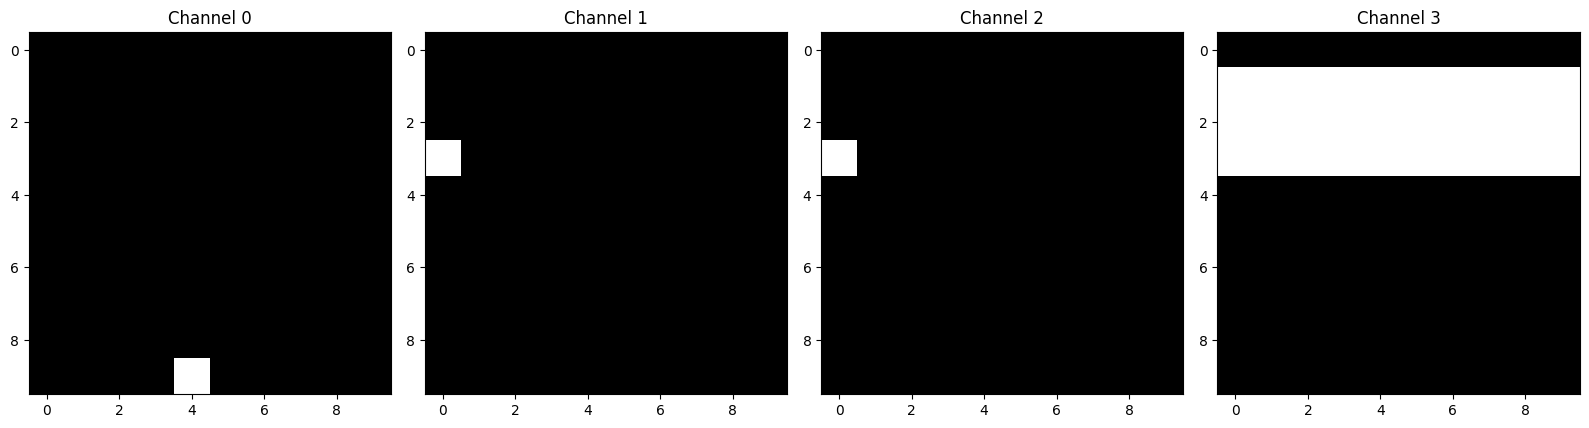

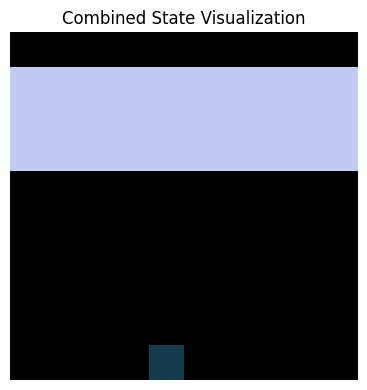

In [8]:
# Reset environment and visualize initial state
state, info = env.reset()
visualize_state_per_channel(state)
visualize_states_grid([state], titles=["Combined State Visualization"])


Step: 1, Action: 1, Reward: 0, Terminated: False, Truncated: False
Step: 2, Action: 1, Reward: 0, Terminated: False, Truncated: False
Step: 3, Action: 2, Reward: 0, Terminated: False, Truncated: False
Step: 4, Action: 1, Reward: 0, Terminated: False, Truncated: False
Step: 5, Action: 1, Reward: 0, Terminated: False, Truncated: False


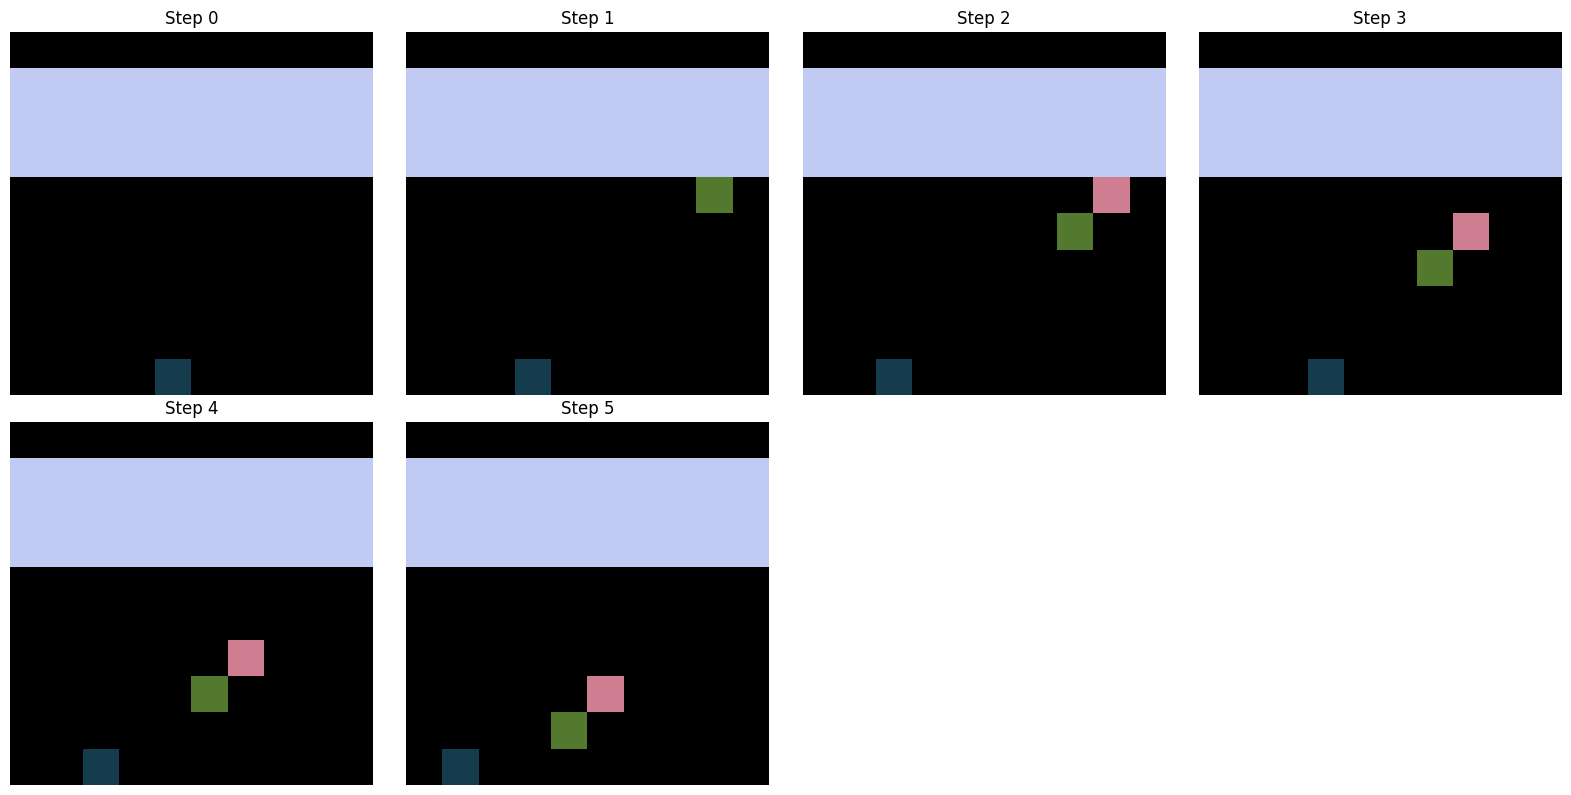

In [10]:
step_states, step_titles = [], []

state, info = env.reset()
step_states.append(state)
step_titles.append(f"Step {0}")

for i in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    print(f"Step: {i + 1}, Action: {action}, Reward: {reward}, Terminated: {terminated}, Truncated: {truncated}")
    step_states.append(next_state)
    step_titles.append(f"Step {i + 1}")

visualize_states_grid(step_states, titles=step_titles, ncols=4)

Legend
- Dark blue = Paddle
- Green = Ball
- Pink = Trailing position of the ball
- Purple = Brick

Here, we take a small number of random actions. The action space is composed of three actions: stay put (0), go left (1), or go right (2). The actions control the paddle. The ball is spawned either from the left or the right side of the screen and moves diagonally. If the ball is falling and is not caught by the paddle, the episode ends.
